# **Imports**

In [93]:
import pandas as pd
import networkx as nx
import community
import random
import csv
import re
import matplotlib.pyplot as plt
from collections import Counter
import itertools 

In [94]:
#I aim to run a co-occurrence on only the comments from Reddit, as they are more insightful than posts
reddit = pd.read_csv("Reddit/clean_40k_comments.csv")
youtube = pd.read_csv("cleaned_youtube_comments.csv")

In [95]:
reddit.head()

,post_id,comment_id,body,score,author,created_utc,cleaned_body
0,1kt8o3b,mtry4sy,TCB's translation is a bit off for Imu's dialo...,1212,adnaphsaka,2025-05-23 03:38:25,tcbs translation bit imu dialogue imu say nani...
1,1kt8o3b,mtrrd7o,It would be classic Oda to finally cut back to...,1732,Brookboy,2025-05-23 02:52:45,would classic oda finally cut back luffys group
2,1kt8o3b,mts2xpb,https://preview.redd.it/o0s6ww1zig2f1.jpeg?wid...,1162,Blue-Diamond-Enjoyer,2025-05-23 04:13:34,holy fuck
3,1kt8o3b,mtrp7pf,Everyone: Elbaf is gonna be Usopp’s arc\n\nOda...,3062,WeAreHereWithAll,2025-05-23 02:39:18,everyone elbaf gon usopps arc oda brook might ...
4,1kt8o3b,mtrp2v6,what \n\n\nWHAT\n\n\nASSUMING DIRECT CONTROL,1306,see_mohn,2025-05-23 02:38:29,assuming direct control


In [96]:
reddit_comments = reddit['cleaned_body'].dropna().tolist()
print(reddit_comments[:10])

['tcbs translation bit imu dialogue imu say nani guzu guzu shiteru seichi ima umi kakujitsu senryoku yosurunoda misete yaru kami shihai taking long holy land sea flame right iwe definitely need military power show reign god note imu us word rulereign shihai luffy used told rayleigh going rule anything', 'would classic oda finally cut back luffys group', 'holy fuck', 'everyone elbaf gon usopps arc oda brook might dad god knight sister mother fucker chapter fucking cracked', 'assuming direct control', 'imu committed silhouette bit even gunkos already wrappedup face get silhouetted hell good guy get situation wtf', 'dragon child parent greatest weakness hell fine gon fall right luffy others probably', 'brook', 'garp said game get stabbed koby gyaban said he rusty get stabbed son whitebeard sick dying stabbed son kuma fly egghead tank stab bonney oden prime got blindsided bonked kaido son cent every parental figure getting hole put losing limb future generation every judge yassop there zef

In [97]:
youtube.head()

,Timestamp,ChannelID,Username,VideoID,Comment,Date,Likes,subscriberCount,cleaned_comment
0,2024-01-29T17:30:55Z,UCv3LuuW8auzYw1SdLmiLRAw,@TotallyNotMark,S63luLJUTmo,Who's your favourite Straw Hat pirate and why?,2024-01-29T17:30:55Z,819,1010000.0,who favourite straw hat pirate
1,2024-01-29T17:32:22Z,UCXFcawqqFE3yGO6zFM_CFVg,@ectospassmta8493,S63luLJUTmo,"I love Usopp, I've always been a fan of underd...",2024-01-29T17:32:22Z,129,23.0,love usopp ive always fan underdog character f...
2,2024-01-29T17:32:25Z,UCVpE0TaPyuxzUYkJs9_Rdcw,@MrAwesomeVVV,S63luLJUTmo,I like franky because he’s such a silly guy :3,2024-01-29T17:32:25Z,81,72.0,franky he silly guy
3,2024-01-29T17:33:19Z,UCMCaUbFLqbObV-BYuAZfT5w,@iamsam-jm5ji,S63luLJUTmo,I’ve gotten to really love Jinbe and how long ...,2024-01-29T17:33:19Z,47,29.0,ive gotten really love jinbe long took become ...
4,2024-01-29T17:34:57Z,UCsbfwXu7RwhKDAZZ5f5f8Bg,@HGmolotov,S63luLJUTmo,"I like zoro, because in spite of the yelling a...",2024-01-29T17:34:57Z,51,9.0,zoro spite yelling simple driven he written su...


In [112]:
yt_comments = youtube['Comment'].dropna().tolist()
print(yt_comments[:10])

["Who's your favourite Straw Hat pirate and why?", "I love Usopp, I've always been a fan of underdog characters that fight the good fight no matter how scared or weak they may be. I love Krillin for the same reason.", 'I like franky because he’s such a silly guy :3', 'I’ve gotten to really love Jinbe and how long it took him to become a straw hat. He really had to fight for it', "I like zoro, because in spite of the yelling and how simple and driven he is, he's written very subtly, plus he has some of my favourite crew dynamics", 'Probably Robin. She has this very smart and dignified air about her, but on the inside she’s rather similar to Luffy. This makes for a pretty fun character because she’s both very intelligent but also has her own brand of silliness', "Jinbei cuz i want him to be my dad :0  he's so lovely and i wanna hug him", "Atm, my favourite is Luffy, I love how he mainly listens to those he interacts with, and then speaks his mind no holds barred, he's also super funny.",

In [99]:
print(f"Youtube comments length: {len(yt_comments)}")
print(f"Reddit comments length: {len(reddit_comments)}")

#Put them in the same file for convenience when implementing the community detection
comments = yt_comments + reddit_comments
print(f"Comments length: {len(comments)}")

Youtube comments length: 51085
Reddit comments length: 38195
Comments length: 89280


# **Preprocessing**

In [100]:
#Define a function that will handle case-sensitive
def extract_character_mentions(text, char_list):
    text = text.lower()
    text = re.sub(r'[’‘”“]', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+|u/\w+', '', text)
    tokens = text.split()

    return list(set([char for char in char_list if char in tokens]))

In [101]:
#Storing characters in a list - These will be the nodes
straw_hats = ['luffy', 'zoro', 'sanji', 'nami', 'chopper', 'usopp', 'jinbei', 'robin', 'franky', 'brook']

# **Character Co-occurrence Count**

Reddit Co-occurrence

In [102]:
reddit_pair_counter = Counter()


for comment in reddit_comments:
    mentioned = extract_character_mentions(comment, straw_hats)
    if len(mentioned) >= 2:
      pairs = itertools.combinations(sorted(mentioned), 2)
      reddit_pair_counter.update(pairs)

print(reddit_pair_counter.most_common)

<bound method Counter.most_common of Counter({('luffy', 'zoro'): 270, ('luffy', 'robin'): 201, ('sanji', 'zoro'): 198, ('luffy', 'sanji'): 173, ('luffy', 'nami'): 152, ('nami', 'robin'): 147, ('robin', 'sanji'): 122, ('chopper', 'luffy'): 116, ('luffy', 'usopp'): 114, ('franky', 'robin'): 113, ('robin', 'zoro'): 110, ('nami', 'sanji'): 104, ('brook', 'robin'): 100, ('chopper', 'robin'): 98, ('brook', 'luffy'): 94, ('franky', 'luffy'): 94, ('nami', 'zoro'): 89, ('brook', 'chopper'): 84, ('robin', 'usopp'): 84, ('sanji', 'usopp'): 82, ('chopper', 'nami'): 82, ('chopper', 'sanji'): 81, ('chopper', 'franky'): 79, ('franky', 'sanji'): 78, ('usopp', 'zoro'): 77, ('franky', 'usopp'): 76, ('brook', 'sanji'): 74, ('brook', 'franky'): 74, ('nami', 'usopp'): 73, ('chopper', 'zoro'): 71, ('brook', 'usopp'): 70, ('chopper', 'usopp'): 70, ('brook', 'zoro'): 70, ('franky', 'zoro'): 67, ('franky', 'nami'): 66, ('brook', 'nami'): 65, ('jinbei', 'luffy'): 24, ('brook', 'jinbei'): 22, ('jinbei', 'sanji')

Youtube Co-occurence

In [103]:
yt_pair_counter = Counter()


for comment in yt_comments:
    mentioned = extract_character_mentions(comment, straw_hats)
    if len(mentioned) >= 2:
      pairs = itertools.combinations(sorted(mentioned), 2)
      yt_pair_counter.update(pairs)

print(yt_pair_counter.most_common)

<bound method Counter.most_common of Counter({('luffy', 'nami'): 1044, ('luffy', 'zoro'): 963, ('sanji', 'zoro'): 848, ('luffy', 'sanji'): 743, ('nami', 'sanji'): 414, ('luffy', 'usopp'): 387, ('luffy', 'robin'): 386, ('nami', 'robin'): 357, ('robin', 'sanji'): 357, ('nami', 'zoro'): 321, ('sanji', 'usopp'): 268, ('brook', 'luffy'): 248, ('nami', 'usopp'): 241, ('brook', 'robin'): 240, ('chopper', 'robin'): 228, ('usopp', 'zoro'): 223, ('franky', 'robin'): 218, ('chopper', 'luffy'): 216, ('robin', 'zoro'): 212, ('brook', 'sanji'): 200, ('chopper', 'sanji'): 194, ('chopper', 'nami'): 184, ('brook', 'franky'): 180, ('franky', 'luffy'): 172, ('chopper', 'zoro'): 158, ('brook', 'zoro'): 156, ('brook', 'chopper'): 155, ('robin', 'usopp'): 146, ('chopper', 'usopp'): 142, ('chopper', 'franky'): 140, ('franky', 'sanji'): 137, ('brook', 'nami'): 129, ('franky', 'zoro'): 128, ('franky', 'nami'): 121, ('franky', 'usopp'): 117, ('brook', 'usopp'): 95, ('jinbei', 'luffy'): 82, ('jinbei', 'sanji'): 

In [104]:
combined_pair_counter = Counter()


for comment in comments:
    mentioned = extract_character_mentions(comment, straw_hats)
    if len(mentioned) >= 2:
      pairs = itertools.combinations(sorted(mentioned), 2)
      combined_pair_counter.update(pairs)

print(combined_pair_counter.most_common)

<bound method Counter.most_common of Counter({('luffy', 'zoro'): 1233, ('luffy', 'nami'): 1196, ('sanji', 'zoro'): 1046, ('luffy', 'sanji'): 916, ('luffy', 'robin'): 587, ('nami', 'sanji'): 518, ('nami', 'robin'): 504, ('luffy', 'usopp'): 501, ('robin', 'sanji'): 479, ('nami', 'zoro'): 410, ('sanji', 'usopp'): 350, ('brook', 'luffy'): 342, ('brook', 'robin'): 340, ('chopper', 'luffy'): 332, ('franky', 'robin'): 331, ('chopper', 'robin'): 326, ('robin', 'zoro'): 322, ('nami', 'usopp'): 314, ('usopp', 'zoro'): 300, ('chopper', 'sanji'): 275, ('brook', 'sanji'): 274, ('chopper', 'nami'): 266, ('franky', 'luffy'): 266, ('brook', 'franky'): 254, ('brook', 'chopper'): 239, ('robin', 'usopp'): 230, ('chopper', 'zoro'): 229, ('brook', 'zoro'): 226, ('chopper', 'franky'): 219, ('franky', 'sanji'): 215, ('chopper', 'usopp'): 212, ('franky', 'zoro'): 195, ('brook', 'nami'): 194, ('franky', 'usopp'): 193, ('franky', 'nami'): 187, ('brook', 'usopp'): 165, ('jinbei', 'luffy'): 106, ('jinbei', 'sanji

## Construct Graph
Establishing the nodes and edges & Visualisation

In [105]:
G_reddit = nx.Graph()
G_yt = nx.Graph()
G_combined = nx.Graph()

#Add the nodes
G_reddit.add_nodes_from(straw_hats)
G_yt.add_nodes_from(straw_hats)
G_combined.add_nodes_from(straw_hats)



#Adding reddit_data edges
for (char1, char2), weight in reddit_pair_counter.items():
    G_reddit.add_edge(char1, char2, weight=weight)


print(f"Reddit | Number of nodes: {G_reddit.number_of_nodes()}")
print(f"Reddit | Number of edges: {G_reddit.number_of_edges()}")
print()


#Adding yt_data edges
for (char1, char2), weight in yt_pair_counter.items():
    G_yt.add_edge(char1, char2, weight=weight)


print(f"YouTube | Number of nodes: {G_yt.number_of_nodes()}")
print(f"YouTube | Number of edges: {G_yt.number_of_edges()}")
print()



#Adding combined_data edges
for (char1, char2), weight in combined_pair_counter.items():
    G_combined.add_edge(char1, char2, weight=weight)


print(f"Combined | Number of nodes: {G_combined.number_of_nodes()}")
print(f"Combined | Number of edges: {G_combined.number_of_edges()}")

Reddit | Number of nodes: 10
Reddit | Number of edges: 45

YouTube | Number of nodes: 10
YouTube | Number of edges: 45

Combined | Number of nodes: 10
Combined | Number of edges: 45


**Reddit Co-occurrence**

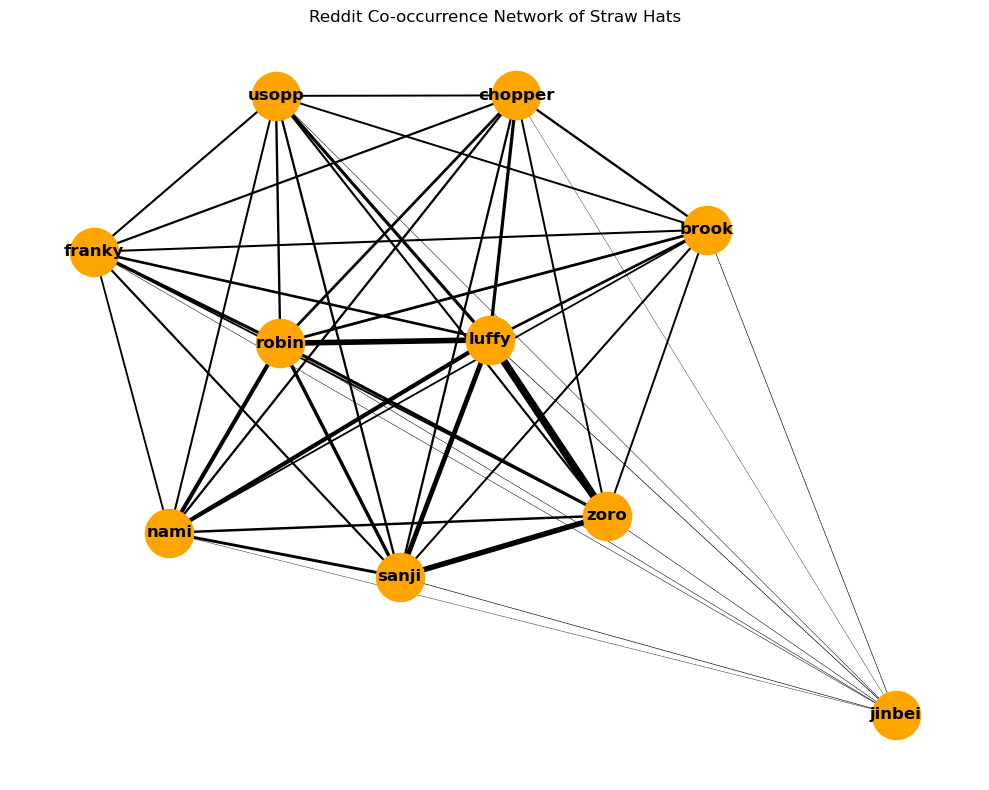

In [113]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_reddit, seed=42)


nx.draw_networkx_nodes(G_reddit, pos, node_color='orange', node_size=1200)

weights = [G_reddit[u][v]['weight'] for u, v in G_reddit.edges()]
nx.draw_networkx_edges(G_reddit, pos, width=[w/50 for w in weights])

#Draw labels
nx.draw_networkx_labels(G_reddit, pos, font_size=12, font_weight='bold')

plt.title("Reddit Co-occurrence Network of Straw Hats")
plt.axis('off')
plt.tight_layout()
plt.show()

**YouTube Co-occurrence**

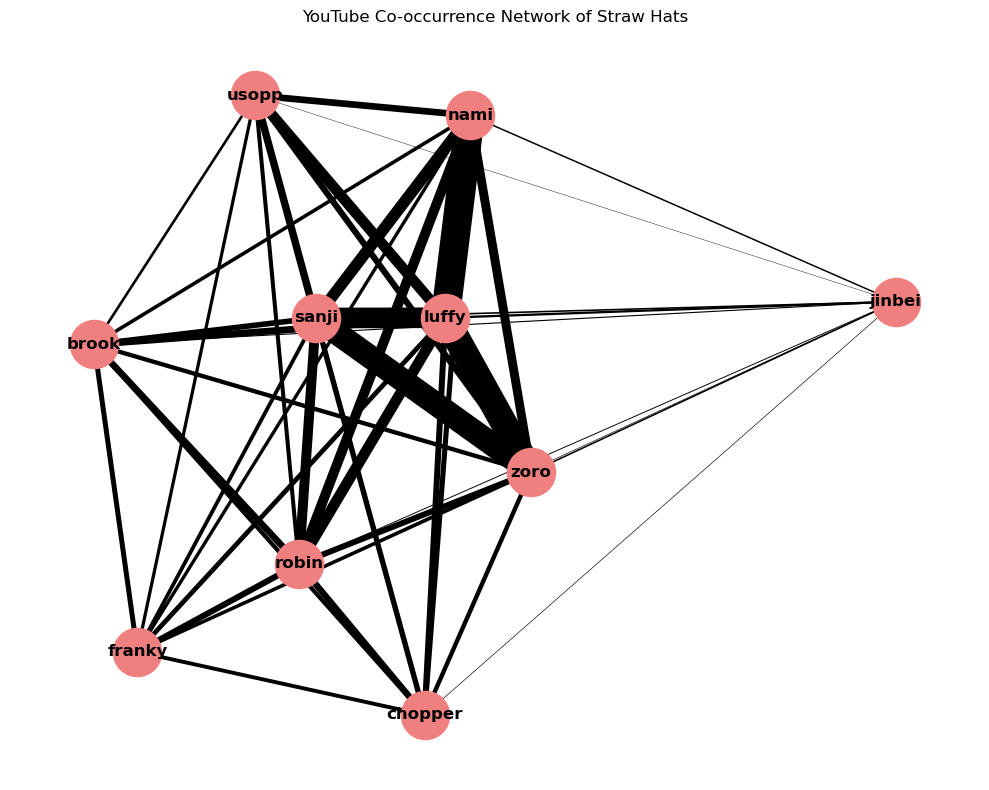

In [114]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_yt, seed=42)


nx.draw_networkx_nodes(G_yt, pos, node_color='lightcoral', node_size=1200)

weights = [G_yt[u][v]['weight'] for u, v in G_yt.edges()]
nx.draw_networkx_edges(G_yt, pos, width=[w/50 for w in weights])

#Draw labels
nx.draw_networkx_labels(G_yt, pos, font_size=12, font_weight='bold')

plt.title("YouTube Co-occurrence Network of Straw Hats")
plt.axis('off')
plt.tight_layout()
plt.show()

**Combined Data Co-occurrence Graph**

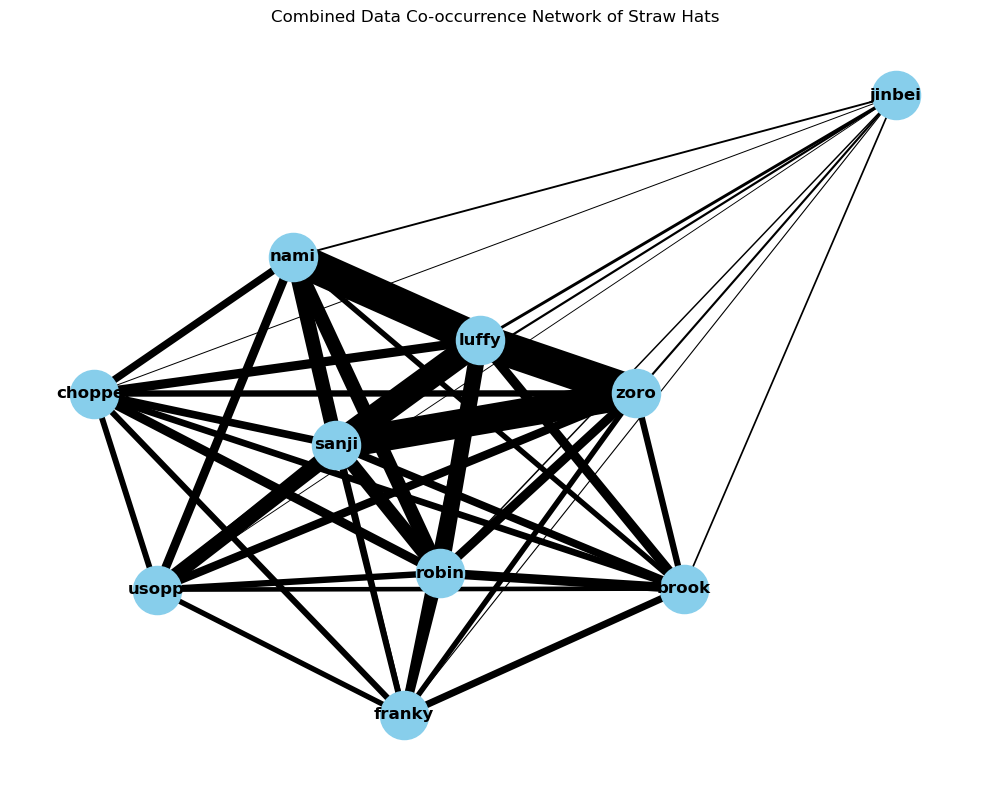

In [115]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_combined, seed=42)


nx.draw_networkx_nodes(G_combined, pos, node_color='skyblue', node_size=1200)

weights = [G_combined[u][v]['weight'] for u, v in G_combined.edges()]
nx.draw_networkx_edges(G_combined, pos, width=[w/50 for w in weights])

#Draw labels
nx.draw_networkx_labels(G_combined, pos, font_size=12, font_weight='bold')

plt.title("Combined Data Co-occurrence Network of Straw Hats")
plt.axis('off')
plt.tight_layout()
plt.show()

In [109]:
#Save graph to .ml
nx.write_graphml(G_reddit, "Reddit_network.graphml")
nx.write_graphml(G_yt, "YouTube_network.graphml")
nx.write_graphml(G_combined, "combined_data_network.graphml")
